In [20]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parents[1]
print(ROOT)

DATA_RAW = ROOT/"data/raw"
DATA_PROCESSED = ROOT/"data/processed"

c:\Users\sebas\PycharmProjects\Git\BoxOffice_Oracle


In [21]:
model_df = pd.read_csv(
    DATA_RAW/"fe_groups/g6.csv"
)

print(model_df.shape)
model_df.head()

(2255, 55)


,Unnamed: 0.1,Unnamed: 0,tconst,primaryTitle,startYear,the_numbers_url,scrape_success,scrape_error,opening_weekend_gross,opening_theaters,...,actor_1_name,actor_2_name,actor_3_name,g6_local_avg_budget_20d,g6_local_median_budget_20d,g6_local_max_budget_20d,g6_num_larger_budget_competitors_20d,g6_budget_percentile_local_20d,g6_budget_vs_local_avg_ratio,g6_budget_vs_local_median_ratio
0,0,1112,tt1311067,Halloween II,2009.0,https://www.the-numbers.com/movie/Halloween-II,True,NaN,7676836.0,1217.0,...,Scout Taylor-Compton,Tyler Mane,Malcolm McDowell,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,1,689,tt0816462,Conan the Barbarian,2011.0,https://www.the-numbers.com/movie/Conan-the-Ba...,True,NaN,9479373.0,1358.0,...,Jason Momoa,Ron Perlman,Rose McGowan,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2,2,1974,tt4731008,The Wild Life,2016.0,https://www.the-numbers.com/movie/Wild-Life-The,True,NaN,4001400.0,1140.0,...,Matthias Schweighöfer,Kaya Yanar,Ilka Bessin,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,980,tt1160419,Dune: Part One,2021.0,https://www.the-numbers.com/movie/Dune,True,NaN,6025091.0,915.0,...,Timothée Chalamet,Rebecca Ferguson,Zendaya,NaN,NaN,NaN,0.0,NaN,NaN,NaN
4,4,1291,tt1540128,Playing for Keeps,2012.0,https://www.the-numbers.com/movie/Playing-for-...,True,NaN,1406300.0,1148.0,...,Gerard Butler,Jessica Biel,Dennis Quaid,NaN,NaN,NaN,0.0,NaN,NaN,NaN


In [22]:
target = "log_opening_weekend_gross"

num_group_features = [
    'g6_local_avg_budget_20d',
    'g6_local_median_budget_20d',
    'g6_local_max_budget_20d',
    'g6_num_larger_budget_competitors_20d',
    'g6_budget_percentile_local_20d',
    'g6_budget_vs_local_avg_ratio',
    'g6_budget_vs_local_median_ratio'
]

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
] + num_group_features

people_features = [
    "director_id",
    "writer_id",
    "actor_1",
    "actor_2",
    "actor_3",
]

cat_group_feature = [

]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
 ] + people_features + cat_group_feature

In [23]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(2255, 25)
(2255,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
y_test_dollars = np.expm1(y_test)

In [26]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [27]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [28]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

{'model': 'Ridge Baseline',
 'r2_log': 0.6140312026781262,
 'mae_log': 0.8147984383213324,
 'mae_dollars': 12226775.516714197}

In [29]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

{'model': 'XGBoost Baseline',
 'r2_log': 0.6691110209426202,
 'mae_log': 0.742824410890186,
 'mae_dollars': 11895880.618270159}

In [30]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.614031,0.814798,1.222678e+07
1,XGBoost Baseline,0.669111,0.742824,1.189588e+07


In [31]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

In [32]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

In [33]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

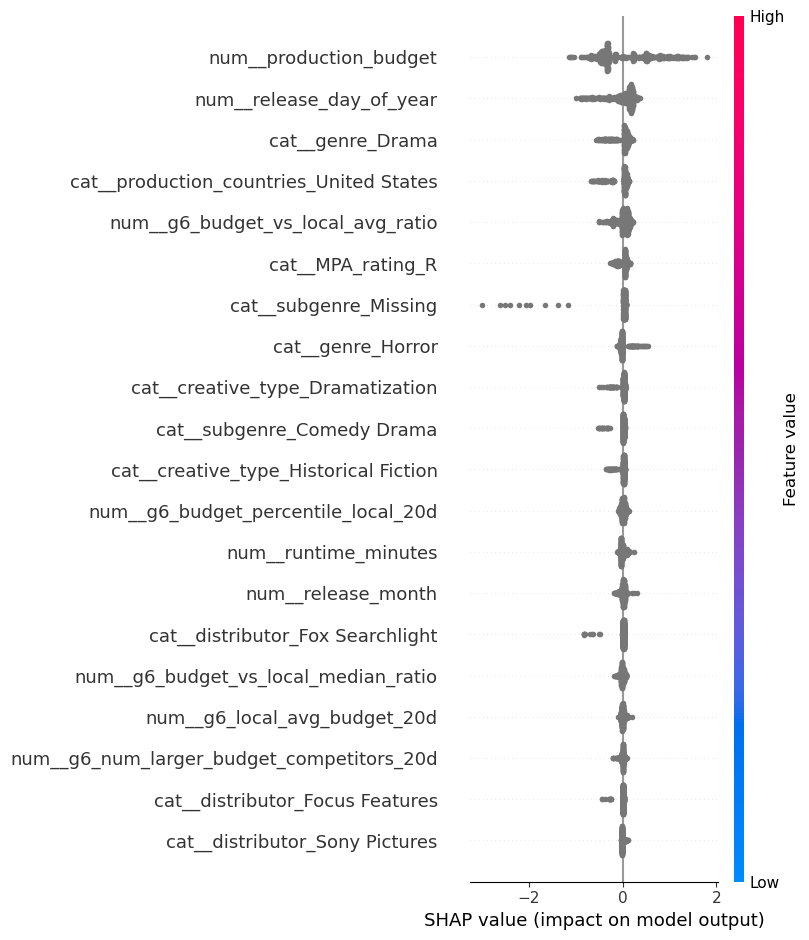

In [34]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

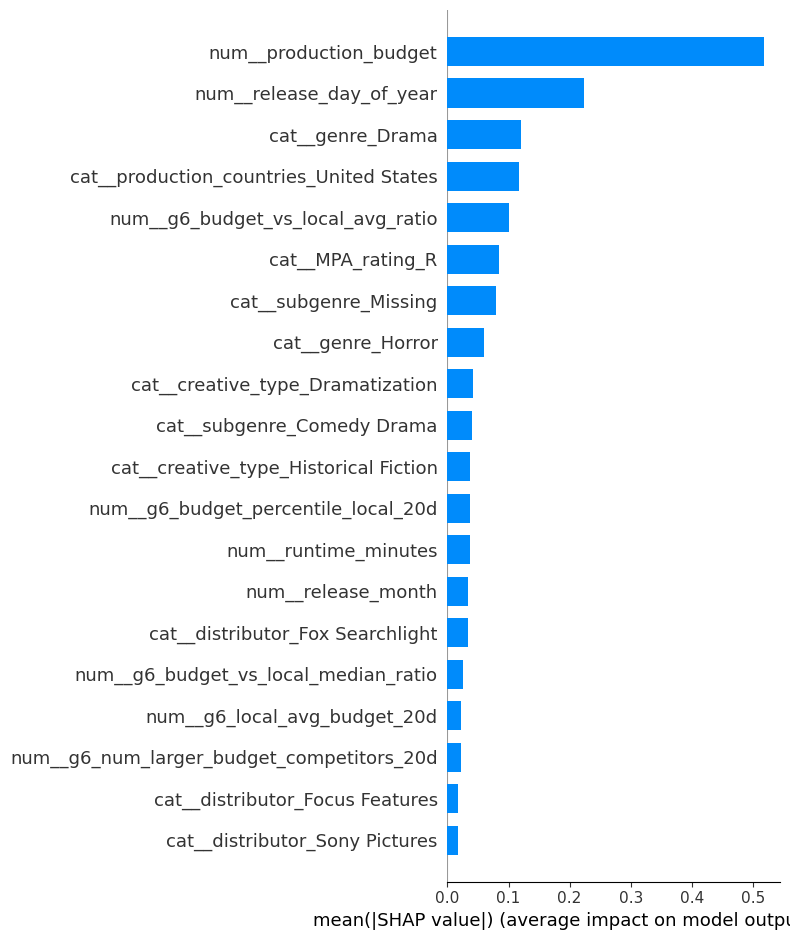

In [35]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [36]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,g6_local_avg_budget_20d,g6_local_median_budget_20d,g6_local_max_budget_20d,g6_num_larger_budget_competitors_20d,g6_budget_percentile_local_20d,g6_budget_vs_local_avg_ratio,...,director_id,writer_id,actor_1,actor_2,actor_3,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
1847,400000000.0,181.0,4,116,2.388889e+07,14000000.0,50000000.0,0.0,1.000000,16.744186,...,nm0751577,nm1321655,nm0000375,nm0262635,nm0749263,19.693568,18.661526,3.571150e+08,127232376.0,2.298826e+08
1620,160000000.0,123.0,3,76,9.333333e+07,120000000.0,185000000.0,1.0,0.777778,1.714286,...,NaN,NaN,nm5177626,nm11380870,nm3592451,18.978870,17.720741,1.747506e+08,49661536.0,1.250891e+08
1619,160000000.0,123.0,3,76,9.333333e+07,120000000.0,185000000.0,1.0,0.777778,1.714286,...,nm0174374,nm0154716,nm0914612,nm1405398,nm1812656,18.978870,17.720741,1.747506e+08,49661536.0,1.250891e+08
1718,200000000.0,120.0,2,47,4.278571e+07,50000000.0,69000000.0,0.0,1.000000,4.674457,...,nm3363032,nm3363032,nm1569276,nm0430107,nm2143282,19.123798,18.256435,2.020040e+08,84853384.0,1.171506e+08
2126,145000000.0,114.0,7,202,1.099286e+08,100000000.0,290000000.0,2.0,0.714286,1.319038,...,nm1950086,nm1950086,nm3053338,nm0331516,nm4793987,18.903243,17.666077,1.620220e+08,47019672.0,1.150024e+08
2204,200000000.0,100.0,6,166,5.770000e+07,50000000.0,100000000.0,0.0,1.000000,3.466205,...,nm1626375,nm0498834,nm0688132,nm1638321,nm10143485,18.853772,17.888700,1.542017e+08,58744052.0,9.545762e+07
1423,74000000.0,91.0,7,191,5.273846e+07,31000000.0,155000000.0,3.0,0.692308,1.403151,...,nm0049633,nm3821363,nm0136797,nm1853544,nm0000273,18.566670,17.305954,1.157184e+08,32800488.0,8.291792e+07
1422,74000000.0,91.0,7,191,5.273846e+07,31000000.0,155000000.0,3.0,0.692308,1.403151,...,nm0049633,nm0528244,nm0000113,nm0358316,nm0000474,18.566670,17.305954,1.157184e+08,32800488.0,8.291792e+07
1832,175000000.0,124.0,3,67,6.012500e+07,53500000.0,129000000.0,0.0,1.000000,2.910603,...,nm1349818,nm1349818,nm0488953,nm0000168,nm0578853,18.848777,18.093212,1.534334e+08,72074592.0,8.135883e+07
1942,205000000.0,110.0,9,247,4.625000e+07,46500000.0,67000000.0,0.0,1.000000,4.432432,...,nm0634240,nm0634240,nm0913475,nm1500155,nm4456120,16.811335,18.410460,2.000185e+07,98983080.0,7.898123e+07


In [37]:
results_df.to_csv(
    DATA_PROCESSED/"feature_testing/g6_model_results.csv",
    index=False
)

error_df.to_csv(
    DATA_PROCESSED/"feature_testing/g6_xgb_test_errors.csv",
    index=False
)